# L2 —— Other 谱系识别
目标：在L1的Other子集当中，进行细胞类型识别

## 环境与路径

In [1]:
# Code cell
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import omicverse as ov

# 路径与文件
DATA_ROOT = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data"
ANNO_DIR  = os.path.join(DATA_ROOT, "06_annotation/L2"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR   = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)

IN_PATH   = os.path.join(DATA_ROOT, "06_annotation/L1/L1_lineage_annotated.h5ad")
OUT_H5AD  = os.path.join(ANNO_DIR, "L2_other_annotated.h5ad")
OUT_CSV   = os.path.join(ANNO_DIR, "L2_other_summary.csv")

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 数据读取 (L1完整数据)

In [2]:
adata = sc.read_h5ad(IN_PATH)
adata

AnnData object with n_obs × n_vars = 374507 × 11743
    obs: 'GSM', 'group', 'GSE', 'leiden_scVI_0.2', 'L1lin_marker', 'L1lin_score', 'L1lin_gpt', 'L1_lineage', 'L1lin_conf'
    var: 'mt'
    uns: 'GSE_colors', 'L1_lineage_colors', 'REFERENCE_MANU', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities'

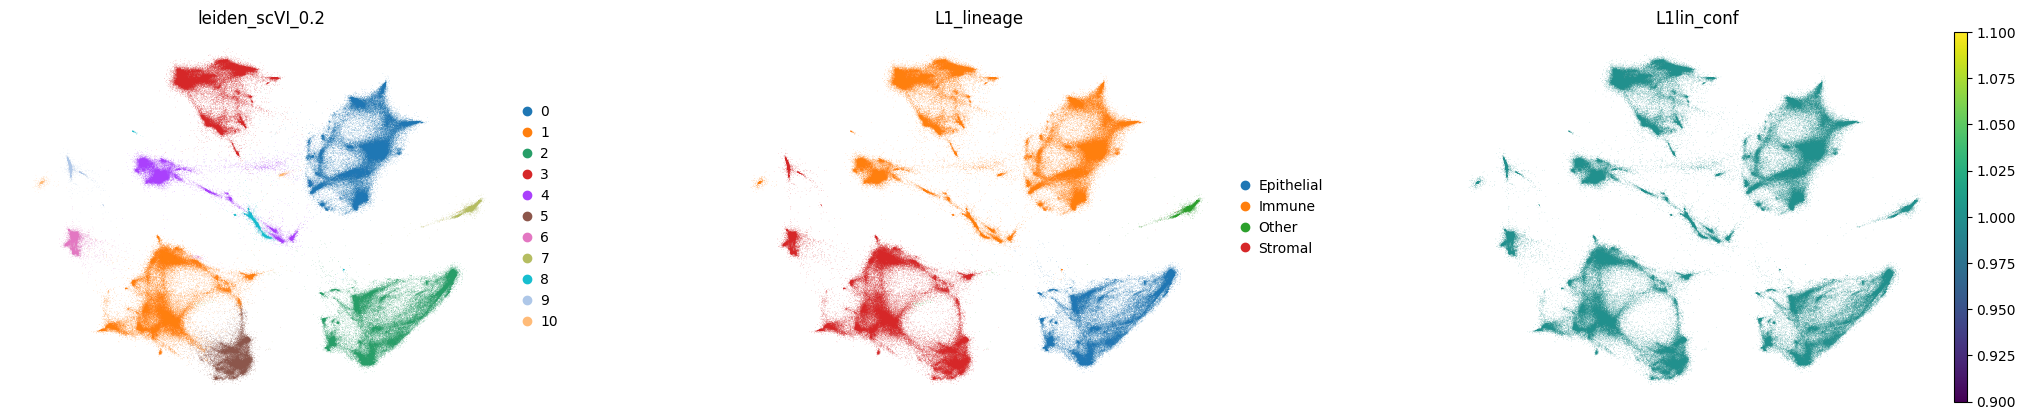

In [3]:
# UMAP
sc.pl.umap(adata, color=["leiden_scVI_0.2", "L1_lineage", 'L1lin_conf'],
           wspace=0.3, frameon=False)

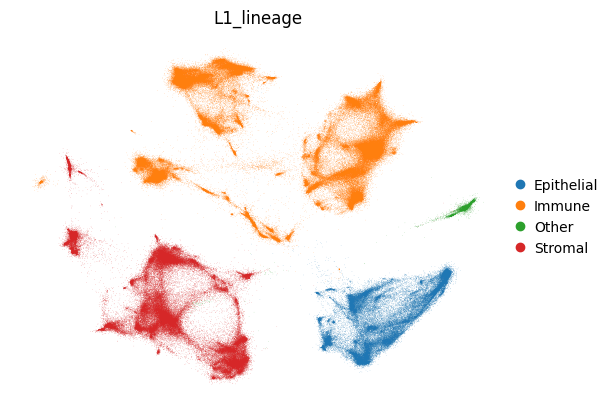

In [4]:
sc.pl.umap(adata, color=["L1_lineage"], frameon=False)

## 可能细胞类型推断
- 神经系统：
    - 肠道神经元
    - 肠道神经胶质

In [5]:
cand_neuro = [
    # 神经元相关
    "TUBB3","STMN2","DCX","NEFL","SNAP25","SYT1","SYN1","RBFOX3",
    # 神经胶质相关
    "SOX10","PLP1","MOBP","GFAP","AQP4","CLDN11","FABP7",
    "S100B","MPZ","GPM6B",
]

[g for g in cand_neuro if g in adata.var_names]

['S100B', 'MPZ', 'GPM6B']

表达矩阵当中神经谱系的marker基因非常少

### 在UMAP上直接看marker表达

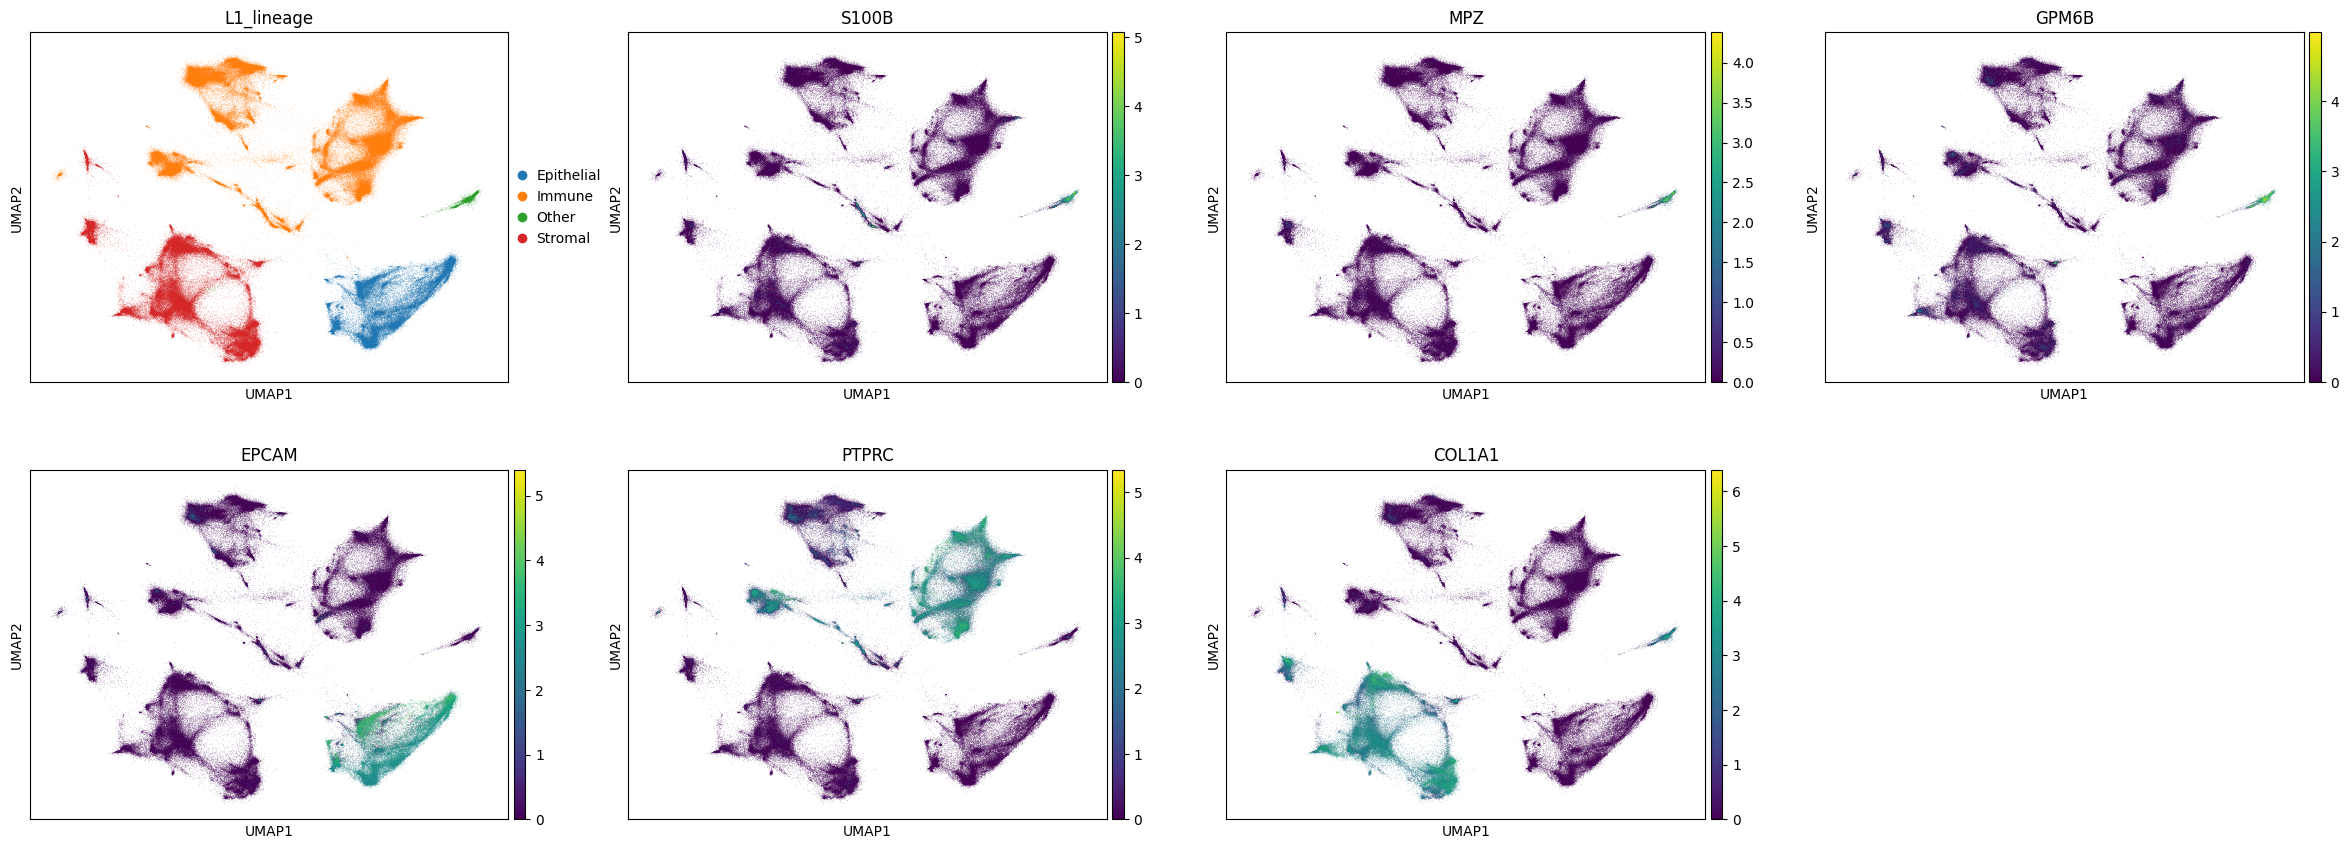

In [6]:
panel = ["S100B","MPZ","GPM6B",
         "EPCAM", "PTPRC","COL1A1"]

panel = [g for g in panel if g in adata.var_names]

import scanpy as sc
sc.pl.umap(
    adata,
    color=["L1_lineage"] + panel,
    ncols=4
)

### 评分查看marker在四个谱系上的分布

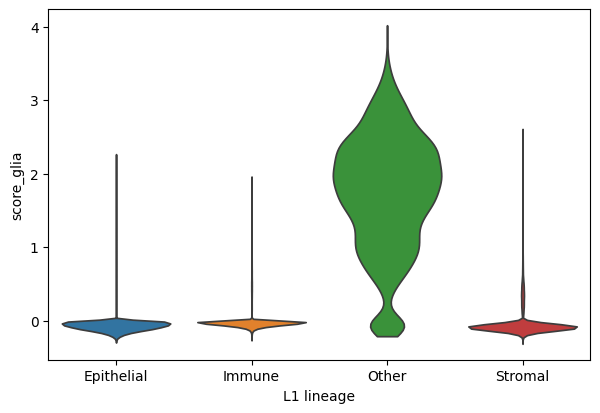

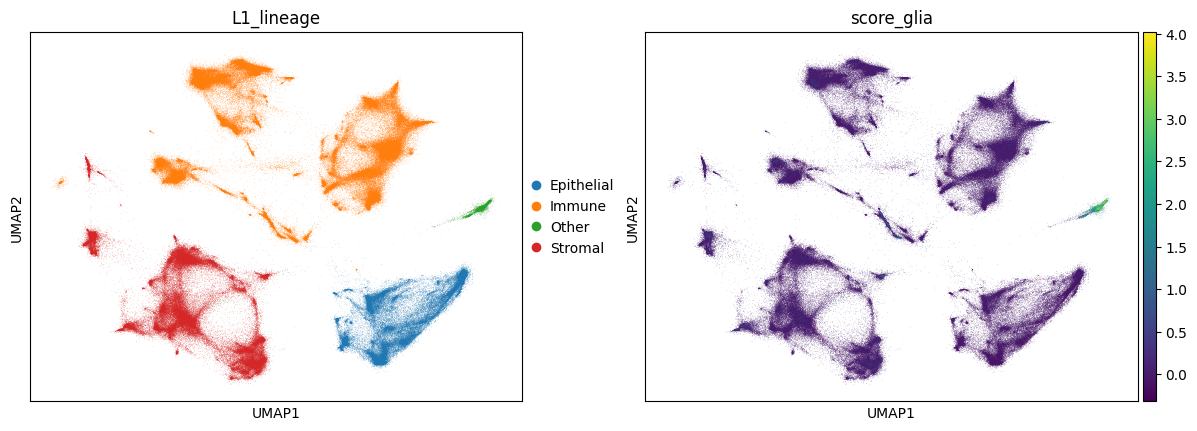

In [7]:
glia_genes = [g for g in ["S100B","MPZ","GPM6B"] if g in adata.var_names]

import scanpy as sc
sc.tl.score_genes(
    adata,
    gene_list=glia_genes,
    score_name="score_glia"
)

sc.pl.violin(
    adata,
    keys="score_glia",
    groupby="L1_lineage",
    stripplot=False
)

sc.pl.umap(
    adata,
    color=["L1_lineage","score_glia"],
    ncols=2
)

### Other marker
做「Other vs 其它所有细胞」的差异分析

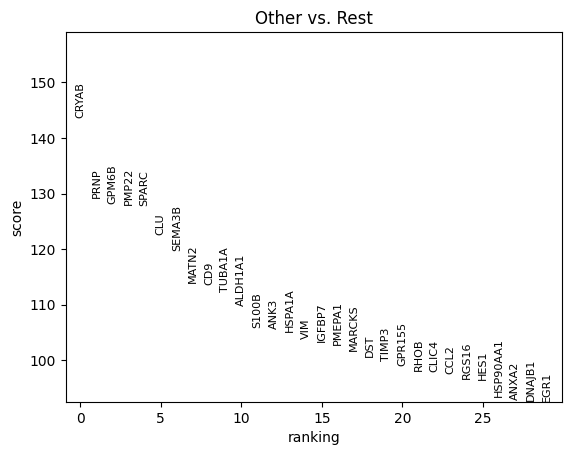

In [8]:
import numpy as np

adata.obs["Other_vs_rest"] = (
    adata.obs["L1_lineage"]
    .eq("Other")
    .map({True: "Other", False: "Rest"})
    .astype("category")
)

sc.tl.rank_genes_groups(
    adata,
    groupby="Other_vs_rest",
    groups=["Other"],
    reference="Rest",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    adata,
    groups=["Other"],
    n_genes=30,
    sharey=False
)

In [9]:
df = sc.get.rank_genes_groups_df(adata, group="Other")
deg_filtered = df[(df["pvals_adj"] < 0.05) & (df["logfoldchanges"] > 0.5)]
deg_filtered.head(30)

,names,scores,logfoldchanges,pvals,pvals_adj
0,CRYAB,143.710648,7.670542,0.0,0.0
1,PRNP,129.172928,4.937297,0.0,0.0
2,GPM6B,128.093155,7.666110,0.0,0.0
3,PMP22,127.940102,4.973096,0.0,0.0
4,SPARC,127.850067,4.704564,0.0,0.0
5,CLU,122.662292,6.017008,0.0,0.0
6,SEMA3B,119.654396,6.241961,0.0,0.0
7,MATN2,113.980713,4.719707,0.0,0.0
8,CD9,113.574242,3.731016,0.0,0.0
9,TUBA1A,112.388107,3.448021,0.0,0.0


前30个marker

In [10]:
top30_genes = deg_filtered["names"].head(30).tolist()
top30_genes

['CRYAB',
 'PRNP',
 'GPM6B',
 'PMP22',
 'SPARC',
 'CLU',
 'SEMA3B',
 'MATN2',
 'CD9',
 'TUBA1A',
 'ALDH1A1',
 'S100B',
 'ANK3',
 'HSPA1A',
 'VIM',
 'IGFBP7',
 'PMEPA1',
 'MARCKS',
 'DST',
 'TIMP3',
 'GPR155',
 'RHOB',
 'CLIC4',
 'CCL2',
 'RGS16',
 'HES1',
 'HSP90AA1',
 'ANXA2',
 'DNAJB1',
 'EGR1']

## 谱系确定
根据三种方法的分析，判断L1当中的Other谱系为肠神经系统

接下来进行L2粗分类